In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

In [ ]:
moldova_df = pd.read_csv('..dataset/moldova.csv')

## Posts timeline

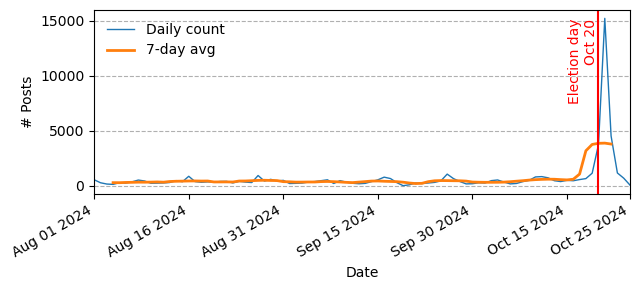

In [ ]:
df = moldova_df.copy()
df['timePublished'] = pd.to_datetime(df['timePublished'], utc=True, errors='coerce')
s = (df.dropna(subset=['timePublished'])
       .set_index('timePublished')
       .resample('D')
       .size()
       .rename('count'))

# Rolling average
s_ma = s.rolling(7, center=True).mean()

fig, ax = plt.subplots(figsize=(6.5, 3.0))
ax.plot(s.index, s, linewidth=1.0, label='Daily count')
ax.plot(s_ma.index, s_ma, linewidth=2.0, label='7-day avg')

# ensure endpoints are included 
start = s.index.min().normalize()
end = s.index.max().normalize()
ax.set_xlim(start, end)
ax.margins(x=0)  

election_day = pd.Timestamp('2024-10-20', tz='UTC') 

ax.axvline(election_day, color='red', linestyle='-', linewidth=1.5)
ax.text(election_day, ax.get_ylim()[1]*0.95, 'Election day\nOct 20', 
        color='red', rotation=90, va='top', ha='right')


ticks = pd.date_range(start, end, freq='15D').union([start, end])
ax.set_xticks(ticks)
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d %Y'))

# ax.set_title('Posts over time (daily) with 7-day rolling average')
ax.set_xlabel('Date')
ax.set_ylabel('# Posts')
ax.grid(True, axis='y', linestyle='--', alpha=1)
ax.legend(frameon=False)
fig.autofmt_xdate()
plt.tight_layout()
plt.show()


## Language Distribution

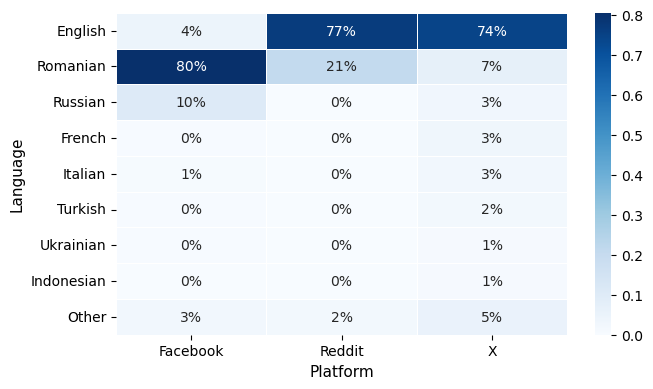

In [ ]:
df = moldova_df.copy()
df['language'] = df['language'].astype(str).str.strip()

df = df[~df['language'].str.lower().isin(['unknown', 'nan', 'none'])]

top_n = 8
top_langs = df['language'].value_counts().head(top_n).index
df['lang_grouped'] = df['language'].where(df['language'].isin(top_langs), 'Other')

mat = pd.crosstab(df['lang_grouped'], df['mediaType'])
mat_share = mat.div(mat.sum(axis=0), axis=1).fillna(0)

# sort by total, but put 'Other' last
order = mat.sum(axis=1).sort_values(ascending=False).index.tolist()
if "Other" in order:
    order = [x for x in order if x != "Other"] + ["Other"]
mat_share = mat_share.loc[order]

# plot heatmap
fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(
    mat_share,
    cmap="Blues",
    annot=True,
    fmt=".0%",
    cbar=True,
    ax=ax,
    linewidths=0.5,
    linecolor="white"
)

# ax.set_title("Language share within each platform", fontsize=13, pad=10)
ax.set_xlabel("Platform", fontsize=11)
ax.set_ylabel("Language", fontsize=11)
plt.tight_layout()
plt.show()